# Introduction

This notebook implements a convolutional neural network (CNN) to predict car brand and model using structured input features.  
The workflow includes:

- data loading and preprocessing
- feature engineering
- building and training a CNN model
- evaluating performance for brand and model predictions
- saving and inference for new samples

Goal: demonstrate an end-to-end ML pipeline where CNN learns to classify brand/model from available attributes.

In [11]:
import pandas as pd 
import numpy as np 
import os
import re
import warnings
warnings.filterwarnings('ignore')

# Load the dataset
df = pd.read_csv('dataset.csv')

# Display the first few rows of the dataset
print(df.head())

print(df.info())

  year\tmake\tmodel\ttrim\tbody\ttransmission\tvin\tstate\tcondition\todometer\tcolor\tinterior\tseller\tmmr\tsellingprice\tsaledate
0  2015\tKia\tSorento\tLX\tSUV\tautomatic\t5xyktc...                                                                                
1  2015\tKia\tSorento\tLX\tSUV\tautomatic\t5xyktc...                                                                                
2  2014\tBMW\t3 Series\t328i SULEV\tSedan\tautoma...                                                                                
3  2015\tVolvo\tS60\tT5\tSedan\tautomatic\tyv1612...                                                                                
4  2014\tBMW\t6 Series Gran Coupe\t650i\tSedan\ta...                                                                                
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 558837 entries, 0 to 558836
Data columns (total 1 columns):
 #   Column                                                                                 

# Data Cleaning

Data cleaning is a crucial early step in the pipeline.  
It ensures the dataset is reliable and consistent before feature engineering or model training.

- Split raw combined string rows into separate logically named columns (`year`, `make`, `model`, etc.).
- Convert types:
    - categorical text to uppercase (standardization)
    - numeric fields (`year`, `odometer`, `mmr`, `sellingprice`, `condition`) to numeric type
    - date strings (`saledate`) to proper `datetime`
- Normalize continuous variables (`condition`) with MinMax scaling so ranges align for ML and comparison.
- Handle missing and invalid values:
    - fill missing or invalid condition with "Unknown" after normalization
    - drop rows where core numeric labels (`mmr`, `sellingprice`, `year`) are missing

Goal:
- eliminate format inconsistencies
- enforce accurate types for calculations
- reduce noise from missing/invalid data
- make downstream analysis/ML resilient and interpretable.

In [12]:
from sklearn.preprocessing import MinMaxScaler

# Create new features based on existing ones, and drop original column
split_columns = df['year\tmake\tmodel\ttrim\tbody\ttransmission\tvin\tstate\tcondition\todometer\tcolor\tinterior\tseller\tmmr\tsellingprice\tsaledate'].str.split('\t', expand=True)
split_columns.columns = ['year','make', 'model', 'trim', 'body', 'transmission', 'vin', 'state', 'condition', 'odometer', 'color', 'interior', 'seller', 'mmr', 'sellingprice', 'saledate']
df_clean = pd.concat([df, split_columns], axis=1)
df_clean.drop(df_clean.columns[0], axis=1, inplace=True)

# Convert all string columns to uppercase
df_upper_case = df_clean.copy()
df_upper_case = df_upper_case.applymap(lambda x: x.upper() if isinstance(x, str) else x)

#Convert saledate to datetime format
df_upper_case['saledate'] = pd.to_datetime(df_upper_case['saledate'], errors='coerce')

# Convert numeric columns to appropriate data types
numeric_columns = ['year', 'odometer', 'mmr', 'sellingprice', 'condition']
for col in numeric_columns:
    df_upper_case[col] = pd.to_numeric(df_upper_case[col], errors='coerce')

# Apply Min-Max scaling to the 'condition' column
scaler = MinMaxScaler()
df_scaled = df_upper_case.copy()
df_scaled['condition_normalized'] = scaler.fit_transform(df_scaled[['condition']])
df_scaled.drop('condition', axis=1, inplace=True)

# Null values in condition as Unknown
df_scaled['condition_normalized'].fillna('Unknown', inplace=True)

# Drop instances where mmr, selingprice, odometer or year is null
df_no_nulls = df_scaled.copy()
df_no_nulls.dropna(subset=['mmr', 'sellingprice', 'odometer', 'year'], inplace=True)

In [13]:
# Standardize the 'body' column by mapping similar values to a common category
df_body_mapping = df_no_nulls.copy()

body_mapping = {
    'SEDAN': 'SEDAN',
    'SUV': 'SUV',
    'TRUCK': 'TRUCK',
    'COUPE': 'COUPE',
    'VAN': 'VAN',
    'ELANTRA COUPE': 'COUPE',
    'G COUPE': 'COUPE',
    'GENESIS COUPE': 'COUPE',
    'G SEDAN': 'SEDAN',
    'MINIVAN': 'VAN',
    ' ': 'UNKNOWN',
    '': 'UNKNOWN',
    'DOUBLE CAB': 'TRUCK',
    'CREWMAX': 'TRUCK',
    'ACCESS CAB': 'TRUCK',
    'KING CAB': 'TRUCK',
    'SUPERCREW': 'TRUCK',
    'CTS COUPE': 'COUPE',
    'EXTENDED CAB': 'TRUCK',
    'E-SERIES VAN': 'VAN',
    'SUPERCAB': 'TRUCK',
    'REGULAR CAB': 'TRUCK',
    'G CONVERTIBLE': 'CONVERTIBLE',
    'KOUP': 'COUPE',
    'QUAD CAB': 'TRUCK',
    'CTS-V COUPE': 'COUPE',
    'G37 CONVERTIBLE': 'CONVERTIBLE',
    'CLUB CAB': 'TRUCK',
    'XTRACAB': 'TRUCK',
    'Q60 CONVERTIBLE': 'CONVERTIBLE',
    'CTS WAGON': 'WAGON',
    'G37 COUPE': 'COUPE',
    'MEGA CAB': 'TRUCK',
    'CAB PLUS 4': 'TRUCK',
    'Q60 COUPE': 'COUPE',
    'CAB PLUS': 'TRUCK',
    'BEETLE CONVERTIBLE': 'CONVERTIBLE',
    'TSX SPORT WAGON': 'WAGON',
    'PROMASTER CARGO VAN': 'VAN',
    'GRANTURISMO CONVERTIBLE': 'CONVERTIBLE',
    'CTS-V WAGON': 'WAGON',
    'RAM VAN': 'VAN',
    'TRANSIT VAN': 'VAN',
    'REGULAR-CAB': 'TRUCK',
    'CREWMAX CAB': 'TRUCK',
    'CREW CAB': 'TRUCK',
}
df_body_mapping['body'] = df_body_mapping['body'].map(body_mapping).fillna(df_body_mapping['body'])

# Display the unique values in the 'body' column after standardization
print(f'Unique values in the "body" column after standardization: {df_body_mapping["body"].unique()}')

print(df_body_mapping.head())



Unique values in the "body" column after standardization: ['SUV' 'SEDAN' 'CONVERTIBLE' 'COUPE' 'WAGON' 'HATCHBACK' 'TRUCK' 'VAN'
 'UNKNOWN']
   year   make                model        trim   body transmission  \
0  2015    KIA              SORENTO          LX    SUV    AUTOMATIC   
1  2015    KIA              SORENTO          LX    SUV    AUTOMATIC   
2  2014    BMW             3 SERIES  328I SULEV  SEDAN    AUTOMATIC   
3  2015  VOLVO                  S60          T5  SEDAN    AUTOMATIC   
4  2014    BMW  6 SERIES GRAN COUPE        650I  SEDAN    AUTOMATIC   

                 vin state  odometer  color interior  \
0  5XYKTCA69FG566472    CA   16639.0  WHITE    BLACK   
1  5XYKTCA69FG561319    CA    9393.0  WHITE    BEIGE   
2  WBA3C1C51EK116351    CA    1331.0   GRAY    BLACK   
3  YV1612TB4F1310987    CA   14282.0  WHITE    BLACK   
4  WBA6B2C57ED129731    CA    2641.0   GRAY    BLACK   

                                   seller      mmr  sellingprice  \
0                 KIA MOTOR

# Visualizations

Use this section to explore key relationships in the cleaned dataset:

- distribution of `sellingprice` and `mmr`
- `odometer` vs `sellingprice`
- average price by `make` / `model` / `body`
- condition impact on price

Plots: 
- histogram of `sellingprice`
- boxplot of `sellingprice` by `body`
- scatter plot `odometer` vs `sellingprice` colored by `condition_normalized`
- bar plot of count per `make`

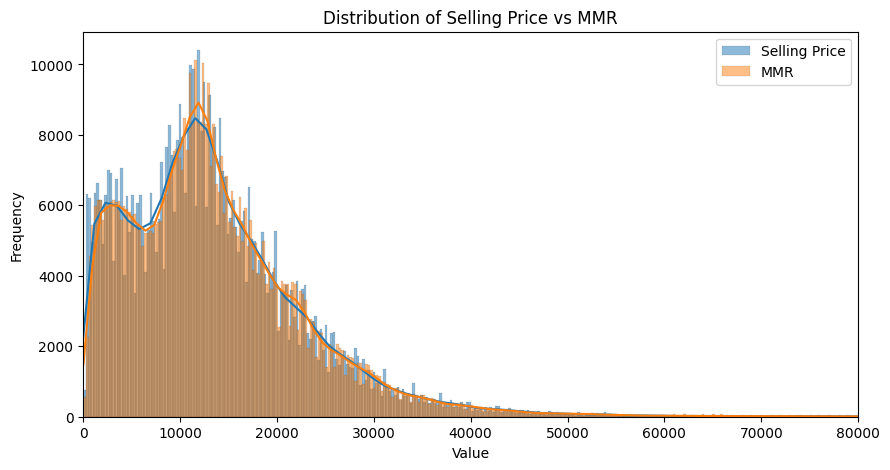

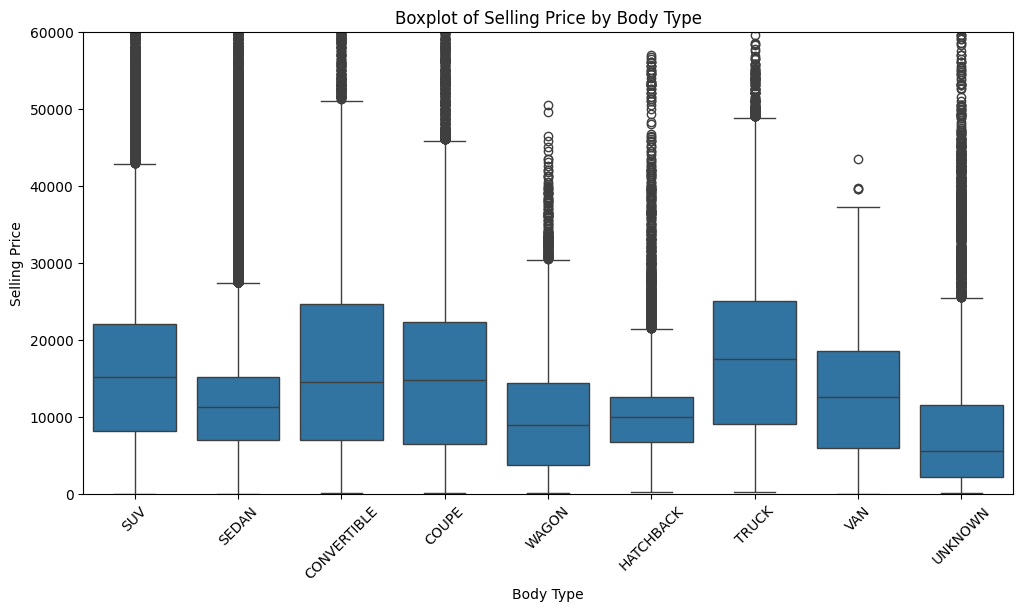

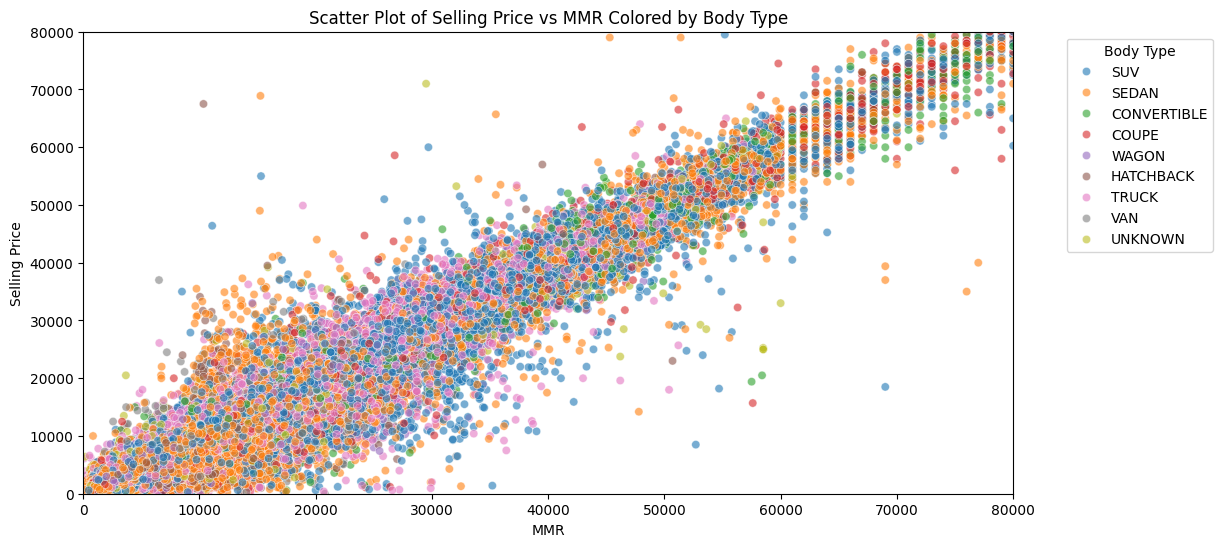

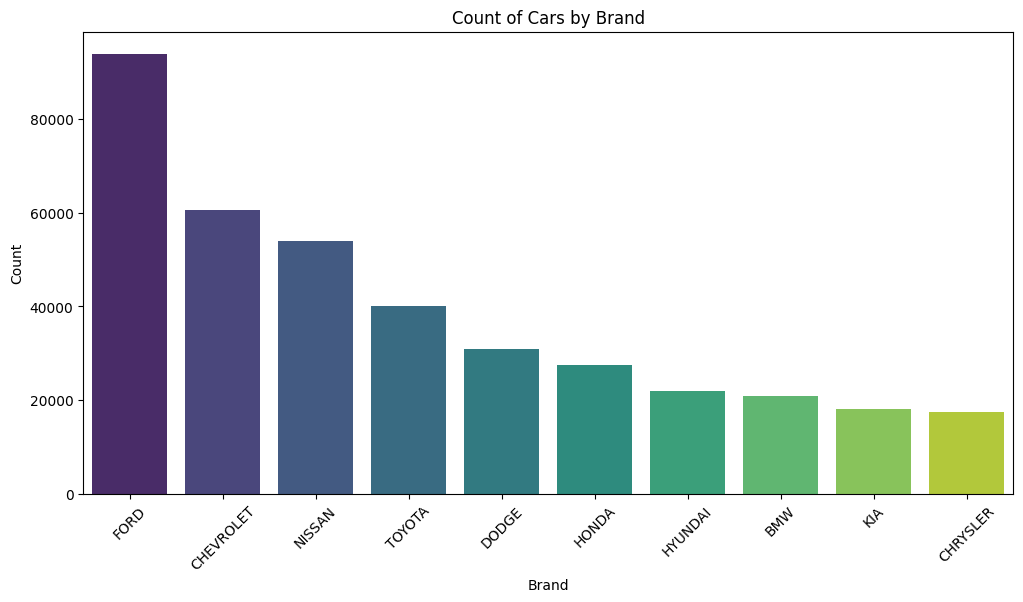

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

df_visualization = df_body_mapping.copy()
df_visualization = df_visualization.drop(columns=['vin', 'saledate', 'seller', 'color', 'interior', 'transmission'])

fig, ax = plt.subplots(figsize=(10, 5))

sns.histplot(df_visualization['sellingprice'], kde=True, label='Selling Price', alpha=0.5, ax=ax)
sns.histplot(df_visualization['mmr'], kde=True, label='MMR', alpha=0.5, ax=ax)

ax.set_title('Distribution of Selling Price vs MMR')
ax.set_xlabel('Value')
ax.set_ylabel('Frequency')
ax.set_xlim(0, 80000)
ax.legend()
plt.show()

# Boxplot of selling price by body type
plt.figure(figsize=(12, 6))
sns.boxplot(x='body', y='sellingprice', data=df_visualization)
plt.title('Boxplot of Selling Price by Body Type')
plt.xlabel('Body Type')
plt.ylabel('Selling Price')
plt.ylim(0, 60000)
plt.xticks(rotation=45)
plt.show()

# Scatter plot of selling price vs mmr colored by body type
plt.figure(figsize=(12, 6))
sns.scatterplot(x='mmr', y='sellingprice', hue='body', data=df_visualization, alpha=0.6)
plt.title('Scatter Plot of Selling Price vs MMR Colored by Body Type')
plt.xlabel('MMR')
plt.ylabel('Selling Price')
plt.xlim(0, 80000)
plt.ylim(0, 80000)
plt.legend(title='Body Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


# Top 10 most soldf car brands
df_top10_make = df_visualization['make'].value_counts().nlargest(10).index
df_top10 = df_visualization[df_visualization['make'].isin(df_top10_make)]
plt.figure(figsize=(12, 6))
sns.countplot(x='make', data=df_top10, order=df_top10['make'].value_counts().index, palette='viridis')
plt.title('Count of Cars by Brand')
plt.xlabel('Brand')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()


# CNN Pipeline: Regression then Classification

In the next steps we will use the same CNN-based architecture for two tasks:

1. Regression:
    - target: `sellingprice`
    - model learns from structured attributes (`year`, `make`, `model`, `body`, `odometer`, `condition_normalized`, etc.)
    - output: continuous price estimate

2. Classification:
    - target(s): car `brand` / `model` (or other categorical labels)
    - model uses similar feature processing and convolutional layers
    - output: discrete class probabilities

This demonstrates a flexible deep learning pipeline where we first validate CNN performance on a regression objective, then adapt to classification on the same cleaned dataset.

In [19]:
import torch
import torch.nn as nn

df_cnn = df_body_mapping.copy()
df_cnn = df_cnn.drop(columns=['vin', 'state', 'seller'])

print(len(df_cnn.columns))

# Regression model to predict selling price based on mmr, condition, odometer, year, etc.
# class CarPricePredictor(nn.Module):
#     def __init__(self):
#         super(CarPricePredictor, self).__init__()
#         self.fc1 = nn.Linear(5, 64)
#         self.relu = nn.ReLU()      
#         self.fc2 = nn.Linear(64, 32)
#         self.fc3 = nn.Linear(32, 1) 

#     def forward(self, x):
#         out = self.fc1(x)
#         out = self.relu(out)
#         out = self.fc2(out)
#         out = self.relu(out)
#         out = self.fc3(out)
#         return out

13
